2026-06-22 10:52:42,097 | INFO | Pipeline started
2026-06-22 10:52:42,097 | INFO | Loading wavelengths
2026-06-22 10:52:42,098 | INFO | Loading data
2026-06-22 10:52:42,449 | DEBUG | Loaded 109 FITS files from 2024-07-29/sun_area/SlitJaw
2026-06-22 10:52:42,449 | DEBUG | Shape of stacked array: (109, 1216, 1936)


  Reading HDF5 from data/hdf
  Reading flats from data/flats
  Reading darks from data/darks


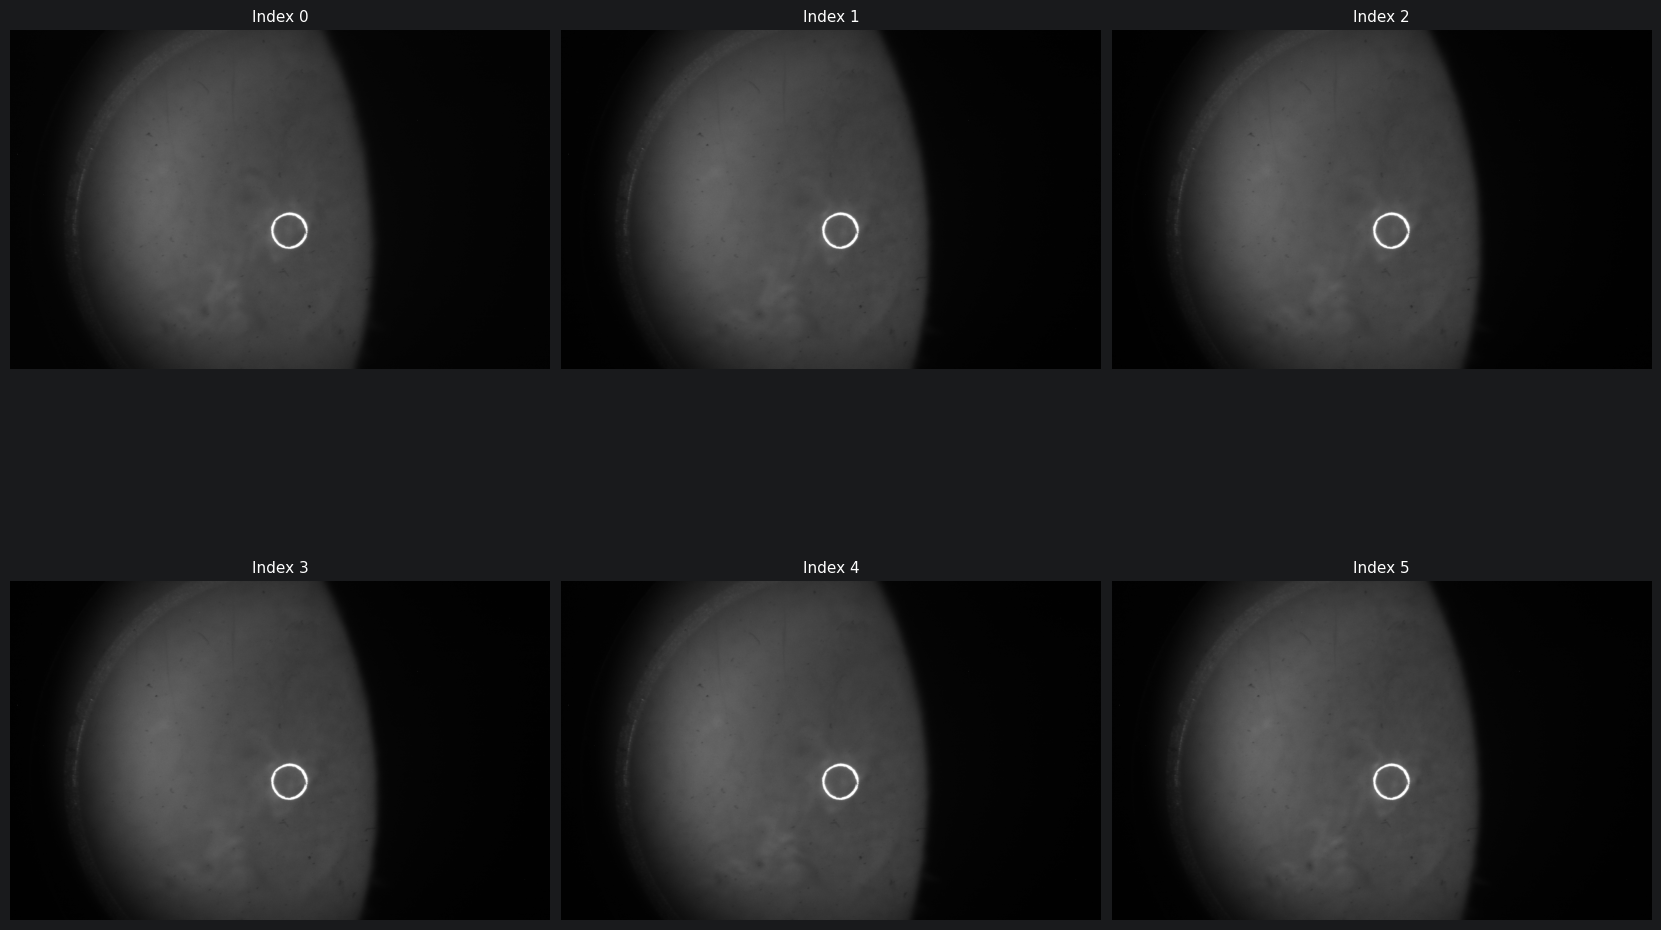

2026-06-22 10:52:43,327 | INFO | Processing data
2026-06-22 10:52:43,328 | INFO | Releasing raw data from memory
2026-06-22 10:52:43,404 | INFO | Analyzing data
2026-06-22 10:52:43,405 | INFO | Plotting results
2026-06-22 10:52:43,405 | INFO | Releasing calibrated data from memory
2026-06-22 10:52:43,473 | INFO | Pipeline finished


  Applying calibration
  Running analysis
  Saving plots to output


In [1]:
from pipeline import Pipeline
import logging
from colorlog import ColoredFormatter

def setup_logger():
    logger = logging.getLogger("pipeline")
    logger.setLevel(logging.DEBUG)

    handler = logging.StreamHandler()

    formatter = ColoredFormatter(
        "%(log_color)s%(asctime)s | %(levelname)s | %(message)s",
        log_colors={
            "DEBUG": "green",     # inside functions
            "INFO": "blue",       # pipeline-level info
            "WARNING": "yellow",
            "ERROR": "red",
            "CRITICAL": "red,bg_white",
        },
    )

    handler.setFormatter(formatter)
    logger.addHandler(handler)
    logger.propagate = False
    return logger


logger = setup_logger()

pipeline = Pipeline(
    fits_dir="2024-07-29/sun_area/SlitJaw",
    hdf_dir="data/hdf",
    flat_dir="data/flats",
    dark_dir="data/darks",
    output_dir="output",
    logger=logger,
)

pipeline.run()




In [5]:
import gc
from data_io import *
from processing import *
from analysis import *
from plotting import *
from FICUS.PYTHON.OCAS_lib import *
from FICUS.PYTHON.NormalizationModule import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.patches import Rectangle

In [3]:
# Define crop bounds
xmn = 900
ymn = 800
x_min, x_max = xmn , xmn +140
y_min, y_max = ymn, ymn +140


# Define circle parameters
circle_center = (70, 64)  # x, y in pixel coordinates of cropped_data
# radius in pixels
circle_radius = 54


# Add rectangle to indicate crop region
rect = Rectangle(
    (x_min, y_min),          # lower-left corner (x, y)
    x_max - x_min,           # width
    y_max - y_min,           # height
    edgecolor='red',
    facecolor='none',
    linewidth=2
)

In [4]:
folder = "./sun_area_flat/SlitJaw"
fits_files = load_fits(folder, logger=logger)

2026-06-22 10:52:53,916 | DEBUG | Loaded 100 FITS files from ./sun_area_flat/SlitJaw
2026-06-22 10:52:53,916 | DEBUG | Shape of stacked array: (100, 1216, 1936)


In [7]:
cropped_images_array = crop_images(fits_files, x_min, x_max, y_min, y_max, logger=logger)


NameError: name 'crop_images' is not defined